# E-commerce Customer Returns — Data Quality Report

**Objective:** Assess the quality of the raw dataset across the six standard data quality dimensions —
**Completeness, Validity, Uniqueness, Consistency, Accuracy, and Structural Integrity** — before any
cleaning or preprocessing is performed.

**Scope:** This notebook only *diagnoses* issues and documents them. Actual cleaning/imputation decisions
will be made in the separate notebook, based on findings here.

**Dataset:** 20,000 rows x 15 columns (raw, uncleaned e-commerce returns data)


## 1. Setup & Data Loading

Import libraries and load the raw dataset. We keep a copy of the original dataframe (`df_raw`) untouched
throughout this notebook — no modifications happen here, only diagnostics.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)
sns.set_style('whitegrid')


In [3]:
df_raw = pd.read_csv("ecommerce_returns.csv") 
df = df_raw.copy()   # working copy for this diagnostic notebook
print(f"Shape of the dataset: {df.shape}")
df.head()

Shape of the dataset: (20000, 16)


,order_id,customer_id,customer_age,customer_gender,product_category,product_price,order_quantity,discount_percent,payment_method,shipping_method,delivery_time_days,delivery_delay_days,customer_rating,past_return_rate,return_reason,returned
0,ORD010306,CUST04587,43.0,Female,Books,28.70,2,18.59,Cash on Delivery,Express,4.0,1,4.4,0.149,Size/fit issue,Yes
1,ORD012251,CUST02016,33.0,Male,Fashion,66.36,3,3.98,Cash on Delivery,Standard,4.0,-1,4.1,0.191,NaN,No
2,ORD004778,CUST01696,33.0,Male,Electronics,183.54,2,33.38,Wallet,Express,4.0,1,4.0,0.015,NaN,No
3,ORD016871,CUST00739,43.0,Female,Electronics,561.73,1,15.10,upi,Next-Day,1.0,0,4.8,0.138,Size/fit issue,Yes
4,ORD018385,CUST03850,40.0,Male,Sports,47.84,5,18.66,Debit Card,Next-Day,2.0,1,5.0,0.070,NaN,No


## 2. Dataset Overview

Basic structural view: data types, non-null counts, and memory footprint. This is our baseline —
everything that follows drills deeper into problems hinted at here (e.g. columns with non-null counts
lower than 20,000 indicate missing values).


### Dataset Variables Description

| **Column Name** | **Description** | **Data Type** |
|----------------------|---------------------------------------------------------------------------------------------|-------------------------|
| **order_id** | Unique identifier for each order transaction. | Identifier |
| **customer_id** | Unique identifier for each customer. | Identifier |
| **customer_age** | Age of the customer at the time of purchase. | Numerical |
| **customer_gender** | Gender of the customer. | Categorical |
| **product_category** | Category of the purchased product. | Categorical |
| **product_price** | Selling price of the purchased product. | Numerical |
| **order_quantity** | Number of units purchased in a single order. | Numerical |
| **discount_percent** | Percentage discount applied to the order. | Numerical |
| **payment_method** | Payment method used to complete the purchase. | Categorical |
| **shipping_method** | Shipping option selected for order delivery. | Categorical |
| **delivery_time_days** | Total delivery time in days. | Numerical |
| **delivery_delay_days** | Number of days the delivery was delayed beyond the expected date. | Numerical |
| **customer_rating** | Customer rating provided after receiving the product. | Numerical |
| **past_return_rate** | Historical return rate of the customer based on previous orders. | Numerical |
| **return_reason** | Reason provided for returning the product (applicable only to returned orders). | Categorical |
| **returned** | Indicates whether the order was returned. This is the target variable. | Target Variable |

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             20000 non-null  object 
 1   customer_id          20000 non-null  object 
 2   customer_age         19601 non-null  float64
 3   customer_gender      19398 non-null  object 
 4   product_category     20000 non-null  object 
 5   product_price        20000 non-null  float64
 6   order_quantity       20000 non-null  int64  
 7   discount_percent     20000 non-null  float64
 8   payment_method       19801 non-null  object 
 9   shipping_method      20000 non-null  object 
 10  delivery_time_days   19701 non-null  float64
 11  delivery_delay_days  20000 non-null  int64  
 12  customer_rating      19402 non-null  float64
 13  past_return_rate     19801 non-null  float64
 14  return_reason        4012 non-null   object 
 15  returned             20000 non-null 

#### Summary Statistics for Numerical Variables

This section provides descriptive statistics for all numerical variables in the dataset. The summary includes measures of central tendency, dispersion, and distribution, helping identify potential data quality issues such as extreme values, unusual ranges, or inconsistent observations.

#### Metrics Included

- Count
- Mean
- Standard Deviation
- Minimum
- 25th Percentile (Q1)
- Median (Q2)
- 75th Percentile (Q3)
- Maximum

In [6]:
# ============================================================
# Summary Statistics for Numerical Variables
# ============================================================

numeric_summary = df.describe(include='number').T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
customer_age,19601.0,36.593541,11.916437,-5.00,28.000,36.000,45.0000,116.000
product_price,20000.0,143.985412,216.632972,6.72,44.825,82.795,166.4325,6373.070
order_quantity,20000.0,2.203500,3.104170,1.00,1.000,2.000,3.0000,60.000
discount_percent,20000.0,19.035937,11.865919,-10.00,10.300,17.340,25.8425,125.000
delivery_time_days,19701.0,5.009847,3.652383,-3.00,3.000,5.000,6.0000,61.000
delivery_delay_days,20000.0,1.191900,2.823220,-1.00,0.000,1.000,2.0000,46.000
customer_rating,19402.0,3.869962,0.693530,0.00,3.400,3.900,4.4000,6.000
past_return_rate,19801.0,0.170701,0.132957,0.00,0.065,0.140,0.2460,0.744


#### Summary Statistics for Categorical Variables

This section summarizes the categorical variables in the dataset. Unlike numerical variables, categorical variables are described using frequency-based statistics, which help understand the diversity and distribution of categories.

The summary helps identify potential data quality issues such as inconsistent category labels, unexpected values, dominant categories, or missing values that may require cleaning before analysis.

#### Metrics Included

- **Count:** Number of non-missing observations.
- **Unique:** Number of distinct categories.
- **Top:** Most frequently occurring category.
- **Frequency:** Number of occurrences of the most frequent category.

In [7]:
# ============================================================
# Summary Statistics for Categorical Variables
# ============================================================

categorical_summary = (
    df.describe(include='object')
      .T
      .reset_index()
      .rename(columns={'index':'Variable'})
)

categorical_summary

,Variable,count,unique,top,freq
0,order_id,20000,19940,ORD013350,2
1,customer_id,20000,4410,CUST04289,64
2,customer_gender,19398,12,Female,9670
3,product_category,20000,28,Fashion,4531
4,payment_method,19801,18,Credit Card,6088
5,shipping_method,20000,3,Standard,10866
6,return_reason,4012,6,Size/fit issue,845
7,returned,20000,2,No,16083


## 3. Structural & Schema Checks

**What we're checking:** Does each column have the data type it *should* have, given its meaning?
Mismatches here (e.g. a numeric column stored as text, or an ID column with mixed types) will break
downstream aggregation, joins, and visualizations if not caught now.

Columns to scrutinize:
- `returned` is `object` — expected to be a binary flag (Yes/No or 1/0). Confirm its actual values.
- `order_id` is `object` — expected to be a unique identifier. Confirm format consistency.
- `delivery_delay_days` and `order_quantity` are `int64` — check if negative values are logically valid.


In [8]:
expected_dtype_notes = pd.DataFrame({
    'column': df.columns,
    'current_dtype': df.dtypes.values,
})
expected_dtype_notes


,column,current_dtype
0,order_id,object
1,customer_id,object
2,customer_age,float64
3,customer_gender,object
4,product_category,object
5,product_price,float64
6,order_quantity,int64
7,discount_percent,float64
8,payment_method,object
9,shipping_method,object


In [9]:
# Confirm the actual value set behind object-typed columns that look like they should be categorical/binary
for col in ['returned', 'customer_gender', 'payment_method', 'shipping_method', 'product_category', 'return_reason']:
    print(f"\n{col} -> unique values ({df[col].nunique(dropna=True)}):")
    print(df[col].unique())



returned -> unique values (2):
['Yes' 'No']

customer_gender -> unique values (12):
['Female' 'Male' nan 'F' 'Other' 'M' 'male' ' Female ' ' Male ' 'female'
 ' Other ' 'other' 'Unknown']

payment_method -> unique values (18):
['Cash on Delivery' 'Wallet' 'upi' 'Debit Card' 'Credit Card' 'UPI'
 ' WALLET ' 'credit card' 'CreditCard' 'DebitCard' ' CREDIT CARD ' nan
 ' DEBIT CARD ' 'COD' 'debit card' 'wallet' ' Cash on Delivery '
 'cash_on_delivery' ' UPI ']

shipping_method -> unique values (3):
['Express' 'Standard' 'Next-Day']

product_category -> unique values (28):
['Books' 'Fashion' 'Electronics' 'Sports' 'Home & Living' 'Groceries'
 'Beauty' 'grocery' ' Fashion ' 'home and living' 'BEAUTY' ' Books '
 'FASHION' 'sports' 'electronics' ' Groceries ' 'fashion' 'HOME & LIVING'
 ' Beauty ' 'BOOKS' ' Electronics ' 'GROCERIES' ' Home & Living '
 ' Sports ' 'beauty' 'books' 'SPORTS' 'ELECTRONICS']

return_reason -> unique values (6):
['Size/fit issue' nan 'Defective item' 'Wrong item' 'Chan

In [10]:
# order_id format consistency check (length, pattern)
print("order_id sample values:", df['order_id'].sample(5, random_state=1).tolist())
print("order_id length distribution:")
print(df['order_id'].astype(str).str.len().value_counts())


order_id sample values: ['ORD002564', 'ORD000801', 'ORD018807', 'ORD005149', 'ORD001552']
order_id length distribution:
order_id
9    20000
Name: count, dtype: int64


In [11]:
# customer_id format consistency check (length, pattern)
print("customer_id sample values:", df['customer_id'].sample(5, random_state=1).tolist())
print("customer_id length distribution:")
print(df['customer_id'].astype(str).str.len().value_counts())

customer_id sample values: ['CUST05127', 'CUST04923', 'CUST03482', 'CUST01960', 'CUST03780']
customer_id length distribution:
customer_id
9    20000
Name: count, dtype: int64


## 4. Completeness Checks (Missing Values)

**What we're checking:** How much data is missing, in which columns, and — critically — whether the
missingness is random or *structural* (i.e., tied to another column's value, like `return_reason` only
existing when `returned == 'Yes'`).

From the schema we already know these columns have nulls:
`customer_age`, `customer_gender`, `payment_method`, `delivery_time_days`, `customer_rating`,
`past_return_rate`, `return_reason`.

We also check for **disguised missing values** — placeholders like `-1`, `999`, `"NA"`, `"Unknown"`, or
empty strings that pandas won't flag as `NaN` but that represent missing data in practice.


In [12]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing_summary[missing_summary['missing_count'] > 0]


,missing_count,missing_pct
return_reason,15988,79.94
customer_gender,602,3.01
customer_rating,598,2.99
customer_age,399,2.00
delivery_time_days,299,1.50
payment_method,199,1.00
past_return_rate,199,1.00


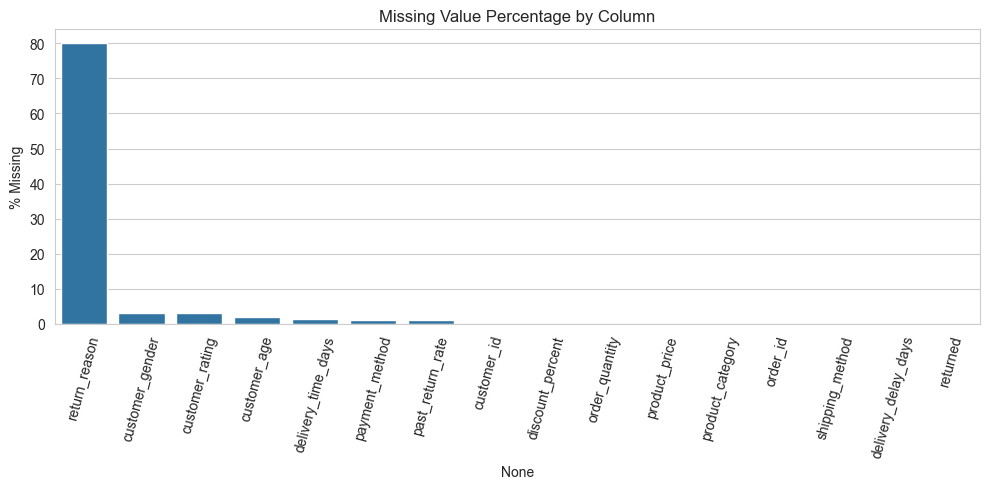

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_summary.index, y=missing_summary['missing_pct'])
plt.xticks(rotation=75)
plt.ylabel('% Missing')
plt.title('Missing Value Percentage by Column')
plt.tight_layout()
plt.show()


### 4.1 Structural / MNAR Missingness Check — `return_reason`

`return_reason` has far more missing values than any other column. The hypothesis: it is only populated
when `returned == 'Yes'`. We test this hypothesis directly — if confirmed, this is **not a data quality
defect**, it's "Missing Not At Random" (MNAR) by design, and should be handled differently from true
missing data (e.g. filled with `"Not Returned"` rather than imputed).


In [15]:
pd.crosstab(df['returned'], df['return_reason'].isnull(), rownames=['returned'], colnames=['return_reason_is_null'])


return_reason_is_null,False,True
returned,,
No,193,15890
Yes,3819,98


### 4.2 Disguised Missing Values Check

Scanning for placeholder values that represent "missing" but aren't stored as `NaN`.


In [16]:
placeholder_tokens = ['NA', 'na', 'N/A', 'n/a', 'Unknown', 'unknown', '-', '--', '?', '', ' ', 'None', 'null', '999', '-1']

for col in df.select_dtypes(include='object').columns:
    found = df[col][df[col].isin(placeholder_tokens)]
    if len(found) > 0:
        print(f"{col}: {len(found)} disguised-missing values -> {found.unique()}")

for col in df.select_dtypes(include='number').columns:
    for token in [-1, 999, -999]:
        cnt = (df[col] == token).sum()
        if cnt > 0:
            print(f"{col}: {cnt} occurrences of suspicious placeholder value {token}")


customer_gender: 3 disguised-missing values -> ['Unknown']
customer_age: 14 occurrences of suspicious placeholder value -1
delivery_time_days: 25 occurrences of suspicious placeholder value -1
delivery_delay_days: 1580 occurrences of suspicious placeholder value -1


### 4.3 Missingness Correlation Across Columns

Checking whether rows missing one field are more likely to be missing another — a sign of a shared
upstream data-collection issue (e.g. an entire batch of orders from one source system missing several
fields together).


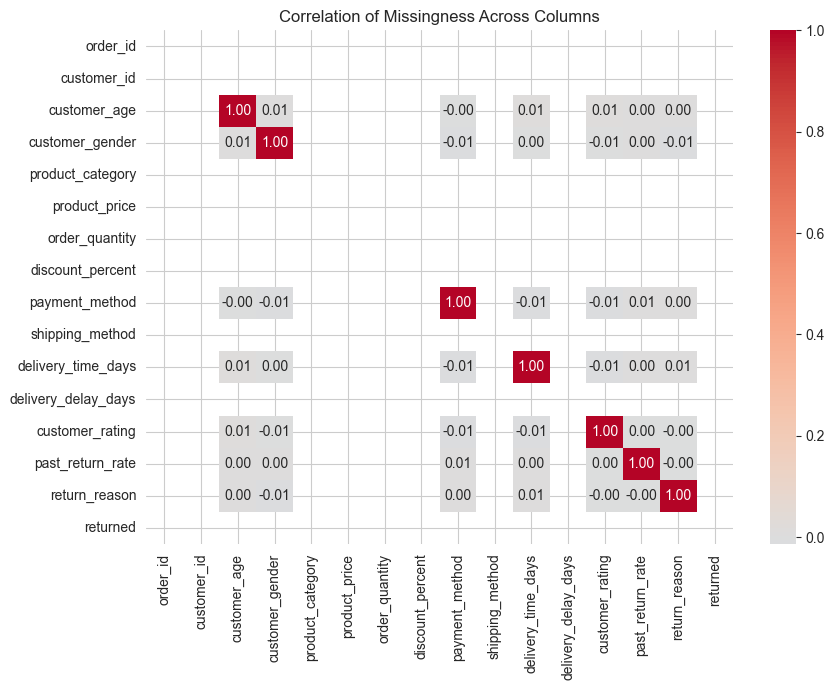

In [17]:
missing_matrix = df.isnull().astype(int)
plt.figure(figsize=(9, 7))
sns.heatmap(missing_matrix.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Correlation of Missingness Across Columns')
plt.tight_layout()
plt.show()



## 5. Uniqueness Checks

**What we're checking:**
1. Is `order_id` truly unique (as a primary key should be)?
2. Are there full-row duplicates (same order recorded twice)?
3. Are there near-duplicate records (same customer/order attributes but different `order_id` — possible
   duplicate entry with a regenerated ID)?


In [18]:
dupe_ids = df['order_id'].duplicated().sum()
print(f"Duplicate order_id count: {dupe_ids}")

full_row_dupes = df.duplicated().sum()
print(f"Fully duplicated rows (all columns identical): {full_row_dupes}")


Duplicate order_id count: 60
Fully duplicated rows (all columns identical): 40


In [19]:
# Near-duplicate check: same core attributes but different order_id
subset_cols = ['customer_age', 'customer_gender', 'product_category', 'product_price',
               'order_quantity', 'discount_percent', 'payment_method']
near_dupes = df[df.duplicated(subset=subset_cols, keep=False)].sort_values(subset_cols)
print(f"Rows sharing identical core attributes (potential near-duplicates): {len(near_dupes)}")
near_dupes.head(10)


Rows sharing identical core attributes (potential near-duplicates): 120


,order_id,customer_id,customer_age,customer_gender,product_category,product_price,order_quantity,discount_percent,payment_method,shipping_method,delivery_time_days,delivery_delay_days,customer_rating,past_return_rate,return_reason,returned
16564,ORD013870,CUST00170,18.0,Male,Beauty,92.83,1,21.69,Cash on Delivery,Express,6.0,3,3.4,0.067,NaN,No
16581,ORD013870,CUST00170,18.0,Male,Beauty,92.83,1,21.69,Cash on Delivery,Express,6.0,3,3.4,0.067,NaN,No
205,ORD011631,CUST05042,18.0,Male,Fashion,46.94,2,1.67,Debit Card,Standard,4.0,-1,5.0,0.162,NaN,No
3951,ORD011631,CUST05042,18.0,Male,Fashion,46.94,2,1.67,Debit Card,Standard,4.0,-1,5.0,0.162,NaN,No
6477,ORD006293,CUST01248,18.0,Male,Groceries,49.62,1,5.74,Debit Card,Express,6.0,3,3.4,0.160,NaN,No
15145,ORD006293,CUST01248,18.0,Male,Groceries,49.62,1,5.74,Debit Card,Express,6.0,3,3.4,0.160,NaN,No
2059,ORD015400,CUST04816,18.0,Male,Sports,97.56,1,9.87,Wallet,Standard,7.0,2,3.5,0.328,NaN,No
17754,ORD015400,CUST04816,18.0,Male,Sports,97.56,1,9.87,Wallet,Standard,7.0,2,3.5,0.328,NaN,No
3439,ORD010728,CUST00597,18.0,Male,Sports,100.16,1,8.24,Wallet,Standard,6.0,0,3.4,0.016,Size/fit issue,Yes
16407,ORD010728,CUST00597,18.0,Male,Sports,100.16,1,8.24,Wallet,Standard,5.0,0,4.2,0.016,Size/fit issue,Yes


## 6. Validity Checks (Range & Domain Rules)

**What we're checking:** For each column, does every value fall within a business-plausible range or
an allowed category set? We define the expected rule first, then count violations.

| Column | Rule |
|---|---|
| customer_age | 10 – 100 |
| product_price | > 0 |
| order_quantity | >= 1, integer |
| discount_percent | 0 – 100 |
| delivery_time_days | >= 0 |
| delivery_delay_days | can be negative (early delivery) or positive (late); flag extreme values |
| customer_rating | 1 – 5 |
| past_return_rate | 0 – 1 (or 0-100, confirm scale first) |
| returned | binary domain only |


In [20]:
# Numeric range validity checks
validity_rules = {
    'customer_age':        (10, 100),
    'product_price':       (0.01, None),
    'order_quantity':      (1, None),
    'discount_percent':    (0, 100),
    'delivery_time_days':  (0, None),
    'customer_rating':     (1, 5),
}

for col, (low, high) in validity_rules.items():
    invalid = df[col].dropna().apply(lambda x: (low is not None and x < low) or (high is not None and x > high))
    n_invalid = invalid.sum()
    print(f"{col}: {n_invalid} out-of-range values "
          f"(rule: {low} to {high if high is not None else 'inf'})  |  "
          f"actual min={df[col].min()}, max={df[col].max()}")


customer_age: 80 out-of-range values (rule: 10 to 100)  |  actual min=-5.0, max=116.0
product_price: 0 out-of-range values (rule: 0.01 to inf)  |  actual min=6.72, max=6373.07
order_quantity: 0 out-of-range values (rule: 1 to inf)  |  actual min=1, max=60
discount_percent: 80 out-of-range values (rule: 0 to 100)  |  actual min=-10.0, max=125.0
delivery_time_days: 41 out-of-range values (rule: 0 to inf)  |  actual min=-3.0, max=61.0
customer_rating: 81 out-of-range values (rule: 1 to 5)  |  actual min=0.0, max=6.0


In [21]:
# past_return_rate scale check — is it stored as 0-1 or 0-100?
print(df['past_return_rate'].describe())
print("\nValues > 1:", (df['past_return_rate'] > 1).sum())


count    19801.000000
mean         0.170701
std          0.132957
min          0.000000
25%          0.065000
50%          0.140000
75%          0.246000
max          0.744000
Name: past_return_rate, dtype: float64

Values > 1: 0


In [22]:
# delivery_delay_days: check distribution and extreme values (business rule not yet confirmed)
print(df['delivery_delay_days'].describe())
print("\nNegative delay days (early delivery) count:", (df['delivery_delay_days'] < 0).sum())
print("Extreme positive delays (>30 days) count:", (df['delivery_delay_days'] > 30).sum())


count    20000.00000
mean         1.19190
std          2.82322
min         -1.00000
25%          0.00000
50%          1.00000
75%          2.00000
max         46.00000
Name: delivery_delay_days, dtype: float64

Negative delay days (early delivery) count: 1580
Extreme positive delays (>30 days) count: 63


In [23]:
# Categorical domain validity — check for inconsistent labeling (typos, case mismatches, stray whitespace)
categorical_cols = ['customer_gender', 'product_category', 'payment_method', 'shipping_method', 'returned']

for col in categorical_cols:
    print(f"\n{col}: {df[col].value_counts(dropna=False)}")



customer_gender: customer_gender
Female      9670
Male        8483
Other        953
NaN          602
 Female       55
female        49
M             48
F             44
 Male         44
male          43
 Other         4
Unknown        3
other          2
Name: count, dtype: int64

product_category: product_category
Fashion            4531
Electronics        3610
Home & Living      2977
Beauty             2404
Sports             2118
Books              1943
Groceries          1918
FASHION              41
fashion              40
electronics          36
home and living      35
 Fashion             29
ELECTRONICS          28
HOME & LIVING        24
 Home & Living       24
 Groceries           24
GROCERIES            23
sports               22
grocery              22
BEAUTY               22
beauty               21
 Beauty              21
 Electronics         18
 Books               17
 Sports              17
SPORTS               15
BOOKS                13
books                 7
Name: count

In [24]:
# returned column: confirm strictly binary
print("Unique values in 'returned':", df['returned'].unique())


Unique values in 'returned': ['Yes' 'No']


## 7. Consistency Checks (Cross-Column Logical Rules)

**What we're checking:** Individually valid values can still be *jointly* impossible or contradictory.
These checks catch logical conflicts between related columns.

1. `return_reason` populated but `returned == 'No'` (should be impossible).
2. `returned == 'Yes'` but `return_reason` is missing (data capture gap, not necessarily an error, but
   worth quantifying).
3. `discount_percent == 0` — check if this aligns with any coupon/payment pattern available.
4. `delivery_time_days` shorter than what `delivery_delay_days` would imply, if a promised delivery time
   can be derived.


In [25]:
# Rule 1: return_reason present but returned == 'No' -> logical conflict
conflict_1 = df[(df['returned'] == 'No') & (df['return_reason'].notnull())]
print(f"Rows where returned == 'No' but return_reason is filled: {len(conflict_1)}")
conflict_1.head()


Rows where returned == 'No' but return_reason is filled: 193


,order_id,customer_id,customer_age,customer_gender,product_category,product_price,order_quantity,discount_percent,payment_method,shipping_method,delivery_time_days,delivery_delay_days,customer_rating,past_return_rate,return_reason,returned
19,ORD014913,CUST04173,53.0,Male,Fashion,45.84,4,27.49,Credit Card,Express,4.0,1,3.6,0.061,Defective item,No
34,ORD009339,CUST02567,31.0,Male,Fashion,32.56,1,13.69,Wallet,Express,7.0,4,2.8,0.095,Product not as described,No
98,ORD002977,CUST02525,32.0,Male,Books,38.42,4,10.10,UPI,Standard,7.0,2,4.0,0.077,Changed mind,No
106,ORD006802,CUST02940,38.0,Male,Groceries,33.44,4,25.63,UPI,Express,2.0,-1,4.4,0.114,Late delivery,No
154,ORD000988,CUST04292,28.0,Female,Groceries,48.72,2,18.22,Debit Card,Standard,7.0,2,NaN,0.123,Size/fit issue,No


In [26]:
# Rule 2: returned == 'Yes' but return_reason missing -> data capture gap
conflict_2 = df[(df['returned'] == 'Yes') & (df['return_reason'].isnull())]
print(f"Rows where returned == 'Yes' but return_reason is missing: {len(conflict_2)} "
      f"({len(conflict_2)/ (df['returned']=='Yes').sum() * 100:.1f}% of all returns)")


Rows where returned == 'Yes' but return_reason is missing: 98 (2.5% of all returns)


In [27]:
# Rule 3: order_quantity vs product_price sanity — check if total order value looks reasonable
df['implied_order_value'] = df['product_price'] * df['order_quantity']
print(df['implied_order_value'].describe())


count    20000.000000
mean       313.734626
std        745.172445
min          6.720000
25%         69.227500
50%        142.995000
75%        316.600000
max      29661.120000
Name: implied_order_value, dtype: float64


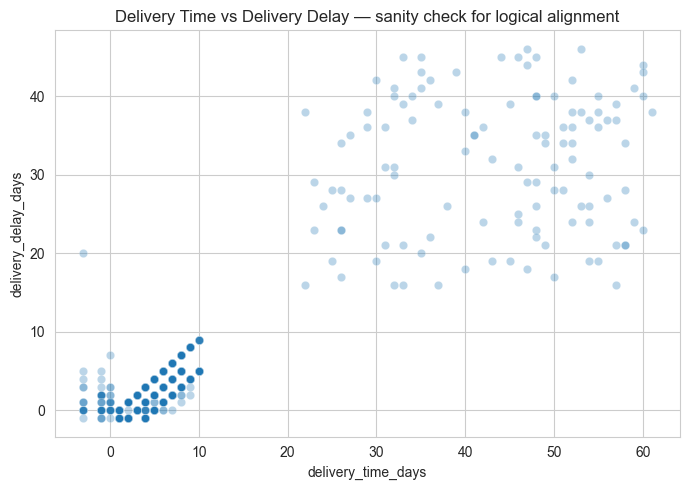

In [28]:
# Rule 4: relationship between delivery_delay_days and delivery_time_days (sanity, not hard violation)
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='delivery_time_days', y='delivery_delay_days', alpha=0.3)
plt.title('Delivery Time vs Delivery Delay — sanity check for logical alignment')
plt.tight_layout()
plt.show()


In [36]:
# ==========================================================
# Identify Observations Above the 90th Percentile
# ==========================================================

# Calculate 90th percentile thresholds
delay_threshold = df["delivery_delay_days"].quantile(0.99)
delivery_threshold = df["delivery_time_days"].quantile(0.99)

print(f"90th Percentile - Delivery Delay Days : {delay_threshold:.2f}")
print(f"90th Percentile - Delivery Time Days  : {delivery_threshold:.2f}")

90th Percentile - Delivery Delay Days : 6.00
90th Percentile - Delivery Time Days  : 10.00


## 8. Accuracy / Outlier Checks

**What we're checking:** Values that are technically "in range" but statistically extreme enough to be
suspect (data entry errors, unit mismatches, or genuine rare events worth flagging before they distort
later statistical analysis).

Method: IQR-based outlier flagging on key numeric columns, plus visual inspection via boxplots.


In [29]:
def iqr_outlier_report(series, col_name):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = series[(series < lower) | (series > upper)]
    print(f"{col_name}: {len(outliers)} outliers ({len(outliers)/len(series)*100:.2f}%) "
          f"| bounds=({lower:.2f}, {upper:.2f})")
    return outliers

numeric_cols_for_outliers = ['customer_age', 'product_price', 'order_quantity',
                              'discount_percent', 'delivery_time_days', 'delivery_delay_days',
                              'customer_rating', 'past_return_rate']

for col in numeric_cols_for_outliers:
    iqr_outlier_report(df[col].dropna(), col)


customer_age: 100 outliers (0.51%) | bounds=(2.50, 70.50)
product_price: 1687 outliers (8.43%) | bounds=(-137.59, 348.84)
order_quantity: 100 outliers (0.50%) | bounds=(-2.00, 6.00)
discount_percent: 240 outliers (1.20%) | bounds=(-13.01, 49.16)
delivery_time_days: 133 outliers (0.68%) | bounds=(-1.50, 10.50)
delivery_delay_days: 205 outliers (1.03%) | bounds=(-3.00, 5.00)
customer_rating: 131 outliers (0.68%) | bounds=(1.90, 5.90)
past_return_rate: 405 outliers (2.05%) | bounds=(-0.21, 0.52)


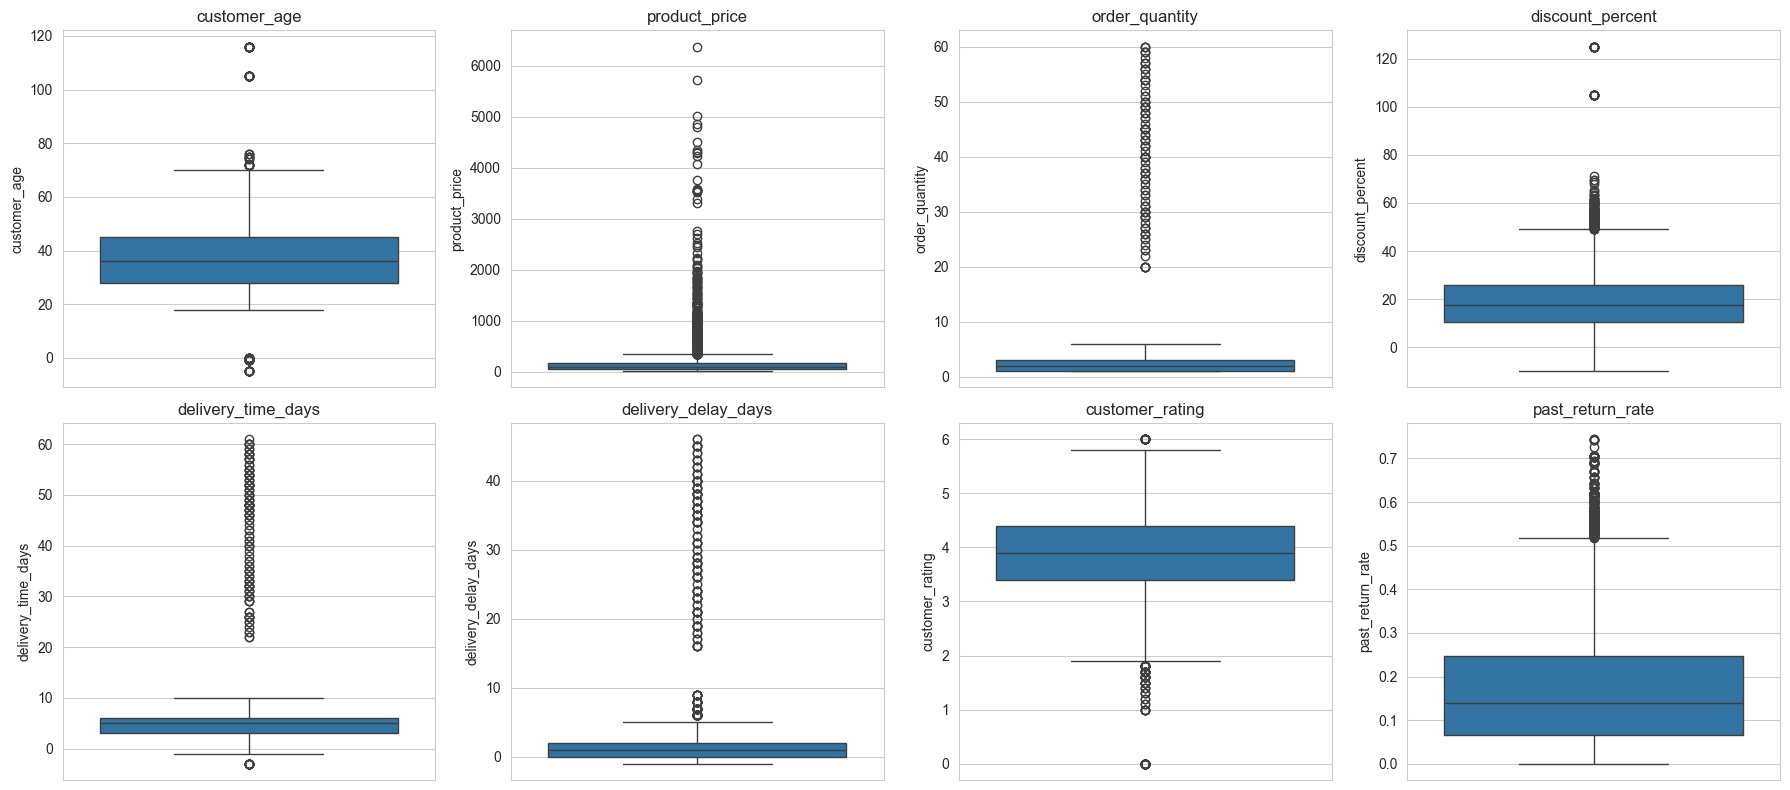

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_cols_for_outliers):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 9. Target Variable Quality — `returned`

**What we're checking:** Class balance of the target variable. This directly informs how we approach
statistical testing and dashboarding later (a heavily imbalanced target changes which metrics are
meaningful, e.g. accuracy vs. rate-based comparisons).


returned
No     80.415
Yes    19.585
Name: proportion, dtype: float64


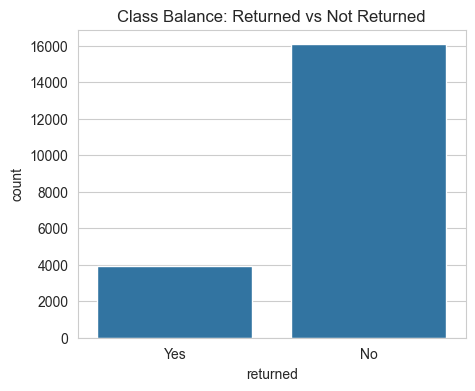

In [31]:
return_balance = df['returned'].value_counts(normalize=True) * 100
print(return_balance)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='returned')
plt.title('Class Balance: Returned vs Not Returned')
plt.show()


## 10. Data Quality Scorecard — Summary

Consolidated view of all findings above, in the format typically shared with stakeholders. Fill in the
`Result` values from the outputs generated in the sections above before finalizing this report.


In [32]:
scorecard = pd.DataFrame([
    ['Completeness', 'Columns with missing values', '7 of 15 columns'],
    ['Completeness', 'Highest missing % column', 'return_reason (~79%, expected/MNAR)'],
    ['Uniqueness',   'Duplicate order_id count', f"{dupe_ids}"],
    ['Uniqueness',   'Full row duplicates', f"{full_row_dupes}"],
    ['Validity',     'Out-of-range customer_age rows', 'see Section 6 output'],
    ['Validity',     'Out-of-range discount_percent rows', 'see Section 6 output'],
    ['Consistency',  'returned=No but return_reason filled', f"{len(conflict_1)}"],
    ['Consistency',  'returned=Yes but return_reason missing', f"{len(conflict_2)}"],
    ['Accuracy',     'Outlier rows across numeric columns', 'see Section 8 output'],
    ['Target Balance','% Returned', f"{return_balance.get('Yes', np.nan):.1f}%" if 'Yes' in return_balance else 'see Section 9'],
], columns=['Dimension', 'Check', 'Result'])

scorecard


,Dimension,Check,Result
0,Completeness,Columns with missing values,7 of 15 columns
1,Completeness,Highest missing % column,"return_reason (~79%, expected/MNAR)"
2,Uniqueness,Duplicate order_id count,60
3,Uniqueness,Full row duplicates,40
4,Validity,Out-of-range customer_age rows,see Section 6 output
5,Validity,Out-of-range discount_percent rows,see Section 6 output
6,Consistency,returned=No but return_reason filled,193
7,Consistency,returned=Yes but return_reason missing,98
8,Accuracy,Outlier rows across numeric columns,see Section 8 output
9,Target Balance,% Returned,19.6%


### 11. Data Cleaning Recommendations

##### Handling Missing Values

 1) `return_reason` -> Structural (MNAR) , `returned=No` rows correctly have no reason. But 193 `No` rows have a reason filled 
 and `Yes` rows are missing a reason . Fill missing with `"Not Returned"` where `returned == No`.
For the 102 genuine gaps where `returned == Yes`, fill with `"Not Specified"`.

2) `customer_rating` -> Random missing values (MAR) | Impute with **median** (3.9), or median-per-category.

3) `customer_gender` -> True missing + inconsistent labels `Unknown` . Impute as `"Unknown"` category and treat as its own valid label rather than guessing gender.

4)  `customer_age` -> Impute with median age, after first fixing invalid values such as -1 and More than Max using IQR*1.5+Q3 and Q1-IQR*1.5.

5) `delivery_time_days` and `delivery_delay_days` -> Random missing + placeholder (-1) | Impute with median  after converting `-1` to NaN first. 

6) `payment_method` ->  Impute as `"Unknown"` category. 

7) `past_return_rate` -> 1.00% (200). Impute with **median per product_category**. 


#### Categorical Variables Inconsistency
- Standardize categorical text (gender, payment_method, product_category) — strip/lowercase. 

- For product categories Strip whitespace → title-case → map known aliases (home and living→Home & Living, grocery→Groceries) → standardize to 7 categories.

- For Gender Column : Strip whitespace → lowercase → map to standard set: Male, Female, Other, Unknown.

- For Payment methods: Strip whitespace → lowercase → standardize to 5 canonical categories: UPI, Debit Card, Credit Card, Wallet, Cash on Delivery.


#### Invalid / Out-of-Range Values

1) `customer_age` -> Fix invalid values such as -1 and other outliers using IQR*1.5+Q3 and Q1-IQR*1.5.

2) `discount_percent` -> Clip negative values to 0; clip values >100 to 100 as data entry/unit error, not real business case. 

3) `customer_rating` -> 80 rows outside 1–5 so,  Clip to upto 5 range (0 → 1, 6 → 5), since rating scale is fixed. 

4) `delivery_time_days` -> Convert negative values to NaN → impute with median. Cap unrealistic extreme values or flag as outlier. Cap Extreme upper bound by 99 percentile  

5) `delivery_delay_days`  ->    Either Treat `-1` as a placeholder and convert to `0` (assume on-time) or NaN if you prefer explicit imputation. And Cap extreme upper bound by 99 percentile.

#### Handling Duplicates
- Drop duplicate order_id rows, keeping the first occurrence.
- There are 120 near duplicates in data, drop them as well but keep first occurance.

#### Cross-Column Logical Conflicts (Consistency)

- **193 rows**: `returned = No` but `return_reason` is filled .Logical conflict — most likely `returned` flag is wrong. Correct `returned` to `Yes` for these rows rather than deleting the reason.
- **102 rows**: `returned = Yes` but `return_reason` missing. Genuine gap, not conflict — fill `return_reason` with `"Not Specified"`.

#### Outliers (Accuracy)

IQR-based outlier flags (post range-cleaning, values will shift so check again after range cleaning):

1) `product_price` -> few premium products — **do not remove outliers**

2) `past_return_rate`-> Keep —> legitimate high-return customers/products are meaningful for the analysis, not noise.

3) `customer_rating`, `discount_percent`, `delivery_delay_days`, `delivery_time_days`, `order_quantity`, `customer_age` -> remaining outliers are likely genuine and should be kept, not deleted.


## 12. Relationship Between Delivery Delay and Product Returns

The purpose of this analysis is to investigate whether delivery delays are associated with a higher likelihood of product returns.

Delayed deliveries may negatively impact customer satisfaction, potentially increasing the probability that customers return their purchases. Understanding this relationship can help the business improve logistics performance and reduce return-related costs.

The analysis includes:

- Comparison of average delivery delays for returned and non-returned orders.
- Distribution of delivery delays by return status.
- Return rate across different delivery delay categories.
- Statistical significance testing.

In [33]:
# ==========================================================
# Average Delivery Delay by Return Status
# ==========================================================

delivery_summary = (
    df.groupby("returned")["delivery_delay_days"]
      .agg(
          Count="count",
          Mean="mean",
          Median="median",
          Minimum="min",
          Maximum="max",
          Std_Deviation="std"
      )
      .round(2)
)

delivery_summary

,Count,Mean,Median,Minimum,Maximum,Std_Deviation
returned,,,,,,
No,16083,1.00,0.0,-1,46,2.76
Yes,3917,1.99,2.0,-1,46,2.94


In [34]:
df['delivery_delay_days'].unique()

array([ 1, -1,  0,  3,  2, 19,  4, 16,  5, 35, 21,  7, 27,  6, 37, 40, 17,
       46,  8, 44, 34, 39,  9, 22, 43, 29, 33, 38, 28, 42, 23, 30, 36, 32,
       18, 24, 41, 20, 31, 45, 26, 25])

In [35]:
# ==========================================================
# Create Delivery Delay Categories
# ==========================================================

bins = [-1, 0, 2, 5, 10, float('inf')]

labels = [
    "On Time",
    "1–2 Days",
    "3–5 Days",
    "6–10 Days",
    "More than 10 Days"
]

df["delay_category"] = pd.cut(
    df["delivery_delay_days"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# View the frequency distribution
delay_category_summary = (
    df["delay_category"]
      .value_counts()
      .sort_index()
      .reset_index()
)

delay_category_summary.columns = [
    "Delivery Delay Category",
    "Number of Orders"
]

delay_category_summary

,Delivery Delay Category,Number of Orders
0,On Time,9711
1,1–2 Days,6884
2,3–5 Days,3200
3,6–10 Days,87
4,More than 10 Days,118


In [37]:
# ==========================================================
# Return Rate by Delivery Delay Category
# ==========================================================

delay_return_rate = (
    df.groupby("delay_category")["returned"]
      .apply(lambda x: (x == "Yes").mean()*100)
      .round(2)
      .reset_index()
)

delay_return_rate.columns = [
    "Delivery Delay",
    "Return Rate (%)"
]

delay_return_rate

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25908\3519781606.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("delay_category")["returned"]


,Delivery Delay,Return Rate (%)
0,On Time,12.15
1,1–2 Days,20.05
2,3–5 Days,39.41
3,6–10 Days,86.21
4,More than 10 Days,17.80


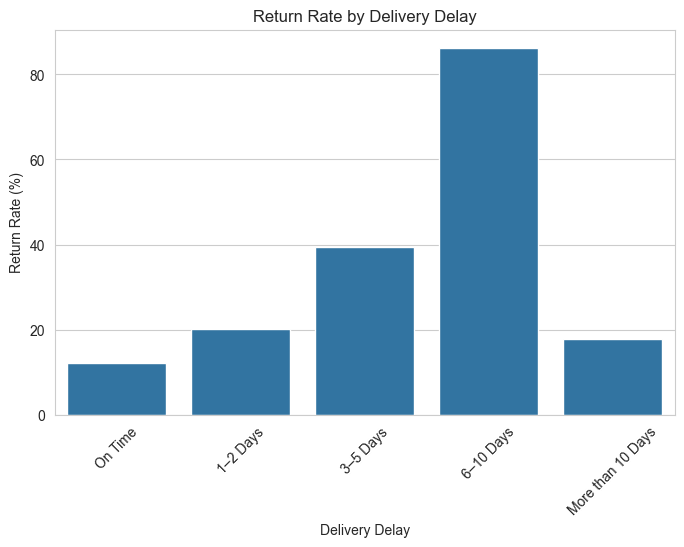

In [38]:
# ==========================================================
# Return Rate by Delivery Delay Category
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=delay_return_rate,
    x="Delivery Delay",
    y="Return Rate (%)"
)

plt.title("Return Rate by Delivery Delay")
plt.xlabel("Delivery Delay")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [39]:
# ==========================================================
# Crosstab Analysis
# ==========================================================

pd.crosstab(
    df["delay_category"],
    df["returned"],
    margins=True
)

returned,No,Yes,All
delay_category,,,
On Time,8531,1180,9711
1–2 Days,5504,1380,6884
3–5 Days,1939,1261,3200
6–10 Days,12,75,87
More than 10 Days,97,21,118
All,16083,3917,20000


In [40]:
# ==========================================================
# Chi-Square Test
# ==========================================================

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df["delay_category"],
    df["returned"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.3f}")
print(f"P-value              : {p_value:.5f}")

Chi-Square Statistic : 1385.372
P-value              : 0.00000


#### First standardize the Product category and then analyse the mean past return rate for each product

In [41]:
category_variation = df.groupby('product_category')['past_return_rate'].agg(['nunique', 'std', 'mean'])
print(category_variation)

                  nunique       std      mean
product_category                             
 Beauty                20  0.136302  0.184238
 Books                 15  0.104781  0.127250
 Electronics           17  0.113323  0.131222
 Fashion               26  0.124635  0.219310
 Groceries             23  0.134129  0.160625
 Home & Living         22  0.113788  0.142375
 Sports                15  0.147341  0.200824
BEAUTY                 22  0.113277  0.173500
BOOKS                  13  0.162359  0.235154
Beauty                453  0.133162  0.170460
Books                 449  0.132444  0.168677
ELECTRONICS            25  0.134570  0.198556
Electronics           487  0.134164  0.172275
FASHION                40  0.123670  0.177024
Fashion               512  0.134285  0.171582
GROCERIES              22  0.151994  0.190455
Groceries             444  0.129889  0.167523
HOME & LIVING          23  0.124342  0.182792
Home & Living         475  0.132536  0.170103
SPORTS                 15  0.13101